In [1]:
from   symxplorer.symbolic_exploration.domains    import Circuit, ExperimentResult, TransmissionMatrixType
from   symxplorer.symbolic_exploration.solver     import Circuit_Solver, Impedance_Analyzer
from   symxplorer.demo.differential               import Common_Gate as CG

from   symxplorer.symbolic_exploration.solver     import run_experiment

import sympy

# Manual Runs

In [ ]:
circuit = CG.circuit
circuit.hasSolution()

In [ ]:
circuit.impedances, circuit.impedancesToDisconnect

In [ ]:
for i, eq in enumerate(circuit.nodal_equations, 1):
    print(f"{i} - {eq}")

In [ ]:
circuit.solve_for

## Circuit Solver

In [ ]:
solver = Circuit_Solver(circuit=circuit, _output= sympy.symbols("Vip Vin"), _input=sympy.symbols("Iip Iin"), transmissionMatrixType=TransmissionMatrixType.SIMPLE)

In [ ]:
solver.impedances

In [ ]:
solver.impedancesToDisconnect

In [ ]:
solver.solve()

In [ ]:
solver.solutions

In [ ]:
symcircuit_sol = solver.baseHs
symcircuit_sol

## Impedance Analyzer

In [ ]:
analysis = Impedance_Analyzer("CG_TIA", circuit_solver=solver)
print(analysis.isCircuitSolved())
analysis

In [ ]:
for block in analysis.impedance_blocks:
    print(f"{block.name} - {block.symbol} - allowed connections {block.allowedConnections}")

In [ ]:
analysis.computeTFs(comboKey="Z1_Z4_ZL")

In [ ]:
analysis.classifier.classifyBiQuadFilters()

In [ ]:
classifications = analysis.classifier.summarizeFilterType()

In [ ]:
analysis.reportSummary("CG_TIA_BiQuad", "Z1_Z4_ZL")

In [ ]:
# analysis.classifier.classifyFilter(filterOrder="FirstOrder")

In [ ]:
classifications = analysis.classifier.summarizeFilterType()

In [ ]:
analysis.reportSummary("CG_TIA_FirstOrder_no_stability_check", "Z1_Z4_ZL")

In [ ]:
analysis.classifier.validate_stability(fType="BP")

In [ ]:
analysis.reportSummary("CG_TIA_FirstOrder_BP_stability_check", "Z1_Z4_ZL")


In [ ]:
analysis.reportType(experimentName="CG_TIA_FirstOrder_BP_stability_check_BP_ONLY", fType="BP", Z_arr="Z1_Z4_ZL")


In [ ]:
analysis.compilePDF()

# Automated Search

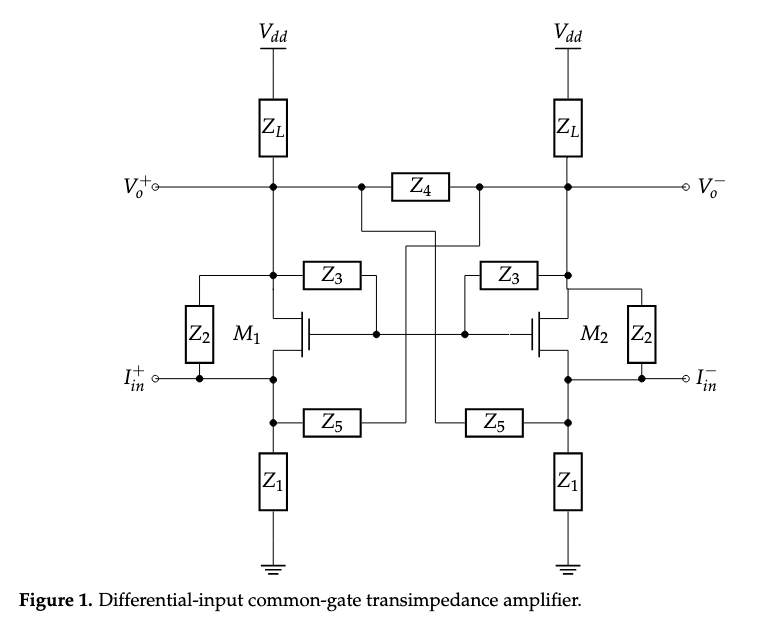

In [ ]:
from   symxplorer.symbolic_exploration.solver     import run_experiment

circuit : Circuit = CG.circuit


experiment_result : ExperimentResult = run_experiment("CG_TIA_Automated",
               T_type=TransmissionMatrixType.SOME_PARASITIC,
               circuit=circuit,
               minNumOfActiveImpedances=2,
               maxNumOfActiveImpedances=2,
            #    impedanceKeysOverwrite=None,
               impedanceKeysOverwrite= [
               #  #    "Z1_Z2_Z3_Z4_Z5_ZL",
               #  #    "Z2_Z3_Z4_Z5_ZL",
               #  #    "Z1_Z3_Z4_Z5_ZL",
               #  #    "Z1_Z2_Z3_Z5_ZL",
               #  #    "Z3_Z4_Z5_ZL",
               #  #    "Z2_Z3_Z5_ZL",
               #  #    "Z1_Z3_Z5_ZL",
               #     "Z1_Z4_ZL",
               #  #    "Z3_Z5_ZL",
                   ],
               outputFrom= ["Vop", "Von"],
               inputFrom=["Iip", "Iin"],
               loadHistory=True
               )


In [ ]:
classifications, tf = experiment_result.get_impedance_key("Z1_Z4_ZL")
tf

In [ ]:
type(classifications), type(classifications[-1])

In [ ]:
df_classifications = experiment_result.flatten_classifications()
df_classifications

In [ ]:
df_tfs = experiment_result.flatten_tfs()
df_tfs

In [ ]:
experiment_result.to_csv()

# No Inductor Exploration

In [ ]:
from   symxplorer.symbolic_exploration.solver     import run_experiment


circuit : Circuit = CG.circuit

# update the circuit parameters
for i in range(len(circuit.impedances)):
    circuit.impedances[i].setAllowedImpedanceConnections([
                                "R",
                                "C",
                                "R | C",
                                "R + C",
                        ])

In [ ]:
experiment_result : ExperimentResult = run_experiment("CG_TIA_Automated_NO_L",
               T_type=TransmissionMatrixType.SOME_PARASITIC,
               circuit=circuit,
               minNumOfActiveImpedances=2,
               maxNumOfActiveImpedances=6,
               impedanceKeysOverwrite=None,
               # impedanceKeysOverwrite= [
               #  #    "Z1_Z2_Z3_Z4_Z5_ZL",
               #  #    "Z2_Z3_Z4_Z5_ZL",
               #  #    "Z1_Z3_Z4_Z5_ZL",
               #  #    "Z1_Z2_Z3_Z5_ZL",
               #  #    "Z3_Z4_Z5_ZL",
               #  #    "Z2_Z3_Z5_ZL",
               #  #    "Z1_Z3_Z5_ZL",
               #     "Z1_Z4_ZL",
               #  #    "Z3_Z5_ZL",
               #     ],
               outputFrom= ["Vop", "Von"],
               inputFrom=["Iip", "Iin"],
               loadHistory=True
               )


In [ ]:
experiment_result.to_csv()

# Cross-coupled Exploration

In [2]:
circuit : Circuit = CG.circuit

# update the circuit parameters
for i in range(len(circuit.impedances)):
    circuit.impedances[i].setAllowedImpedanceConnections([
                                "R",
                                "C",
                                "R | C",
                                "R + C",
                                "L | C",
                                "L + C"
                        ])

In [4]:
# Z1, ZL    always connected
# Z3 Z4 Z5  disconnect
experiment_result : ExperimentResult = run_experiment("CG_TIA_Automated_CROSS_COUPLED",
               T_type=TransmissionMatrixType.SOME_PARASITIC,
               circuit=circuit,
               minNumOfActiveImpedances=2,
               maxNumOfActiveImpedances=6,
            #    impedanceKeysOverwrite=None,
               impedanceKeysOverwrite= [
                   "Z1_Z3_Z4_Z5_ZL",
                   "Z1_Z3_ZL",
                   "Z1_Z3_Z5_ZL",
                   "Z1_Z4_ZL",
                   "Z1_Z5_ZL",
                   ],
               outputFrom= ["Vop", "Von"],
               inputFrom=["Iip", "Iin"],
               loadHistory=True
               )



--- Found a unique pkl file at Runs/CG_TIA_Automated_CROSS_COUPLED_some_parasitic/results_circuit_solution.pkl
--- Updated the circuit solver
Loading the circuit solver from past runs
** Loading the circuit history
Found a unique results.pkl file at Runs/CG_TIA_Automated_CROSS_COUPLED_some_parasitic
** Found 4 keys already computed
Experiment keys: ['Z1_Z3_Z4_Z5_ZL']
Experiment will be ran for 1 keys: ['Z1_Z3_Z4_Z5_ZL']
--> Running the CG_TIA_Automated_CROSS_COUPLED_some_parasitic Experiment for Z1_Z3_Z4_Z5_ZL (1/1)

combo key = Z1_Z3_Z4_Z5_ZL


Getting the TFs (CG): 100%|██████████| 7776/7776 [07:39<00:00, 16.92combo/s]


Number of transfer functions found: 7776


Computing Biquad filter parameters: 100%|██████████| 7776/7776 [05:12<00:00, 24.90filter/s]


summarizing for filters in ['AP', 'BP', 'BS', 'GE', 'HP', 'LP', 'X-INVALID-NUMER', 'X-INVALID-ORDER', 'X-INVALID-WZ', 'X-PolynomialError']
AP : 0
BP : 38
BS : 4
GE : 2
HP : 0
LP : 52
X-INVALID-NUMER : 243
X-INVALID-ORDER : 7419
X-INVALID-WZ : 18
X-PolynomialError : 0
LaTeX report generated and saved to: Runs/CG_TIA_Automated_CROSS_COUPLED_some_parasitic/CG_TIA_Automated_CROSS_COUPLED_some_parasitic_Z1_Z3_Z4_Z5_ZL/CG_TIA_Automated_CROSS_COUPLED_some_parasitic_Z1_Z3_Z4_Z5_ZL_summary.tex

=== ExperimentResult saved successfully to Runs/CG_TIA_Automated_CROSS_COUPLED_some_parasitic/results.pkl - 24666.629 kb ===

<----> END OF EXPERIMENT <---->
Impedance Keys analyzed (count: 1): 
['Z1_Z3_Z4_Z5_ZL']
